In [1]:
fname = "C:/Users/dinab/Desktop/PhD Projects/Elsa Olesya/stata/stata13_se"

In [3]:
import pandas as pd
import numpy as np

In [8]:
df3 = pd.read_stata("ELSA data/h_elsa_g3.dta")

# Dictionary

## Demographic variables

## Health

## Congnition and Behaviour

Pain 
 R1PAINFR         r1painfr:w1 r frequent problems with pain   
 R1PAINLV         r1painlv:w1 r usual level of pain    
 R1LEGPN          r1legpn:w1 r pain in legs              

Urinary Incontinence 
 R1URINAI         r1urinai:w1 r any urinary incontinence      

Persistent Health Problems 
 R1BREATH_E       r1breath_e:w1 r short of breath while walking   
 R1WHEEZE_E       r1wheeze_e:w1 r persistent wheezing
 

# Getting the data 

In [57]:
df3.shape #19,802 x 11,779

(19802, 11791)

In [27]:
# add date1. ... date9 to the dataframe from month and year - to df 
df3 = df3.assign(date1 = df3.r1iwindy + round(df3.r1iwindm/12,2), date2 = df3.r2iwindy + round(df3.r2iwindm/12,2),
                   date3 = df3.r3iwindy + round(df3.r3iwindm/12,2), date4 = df3.r4iwindy + round(df3.r4iwindm/12,2),
                   date5 = df3.r5iwindy + round(df3.r5iwindm/12,2), date6 = df3.r6iwindy + round(df3.r6iwindm/12,2),
                   date7 = df3.r7iwindy + round(df3.r7iwindm/12,2), date8 = df3.r8iwindy + round(df3.r8iwindm/12,2), 
                   date9 = df3.r9iwindy + round(df3.r9iwindm/12,2))


### Adding socio-demographic variables

In [1097]:
# start creating data frame with only what we need
mydf = df3[["idauniq"]]

In [1099]:
# --- add year of birth and died, yod, yob -- 
mydf = mydf.assign(yob = df3.rabyear, yod = df3.radyear)
# --- sex --
mydf['sex'] = df3['ragender'].map({'1.man': 0, '2.woman': 1}).fillna(np.nan)
#--- ethnic group  --
mydf['eth'] = df3['raracem'].map( {'1.white' : 0, '4.non-white':1})
#--- education --
mydf['edu'] = df3['raeducl'].map( {'1.less than upper secondary' : 1, '3.tertiary':3, 
                                   '2.upper secondary and vocational training':2,'.o:other' :2 }) #group other into 2 for "training" etc  mydf.edu.value_counts()
#--- wealth in quintiles --
#mydf["wealth9"] =  pd.qcut(df3['h9atotb'], q=5, labels=[1, 2, 3, 4, 5]) #in categorical format 
#mydf["wealth9"] = mydf["wealth9"].astype("float") # convert to numeric
#same as above in a loop
for i in range(1, 10):
    col_name = f'h{i}atotb'
    new_col_name = f'wealth{i}'
    mydf[new_col_name] = pd.qcut(df3[col_name], q=5, labels=[1, 2, 3, 4, 5])
    mydf[new_col_name] = mydf[new_col_name].astype('float')  # Convert to numeric
# add mean wealth for each person in case some years are missing (row-wise imputation so to say)
mydf["wealth"] = mydf.loc[:, [f'wealth{i}' for i in range(1, 10)]].mean(axis=1) 
# sum(np.isnan(mydf.wealth)) # 147 - only few are missing 
mydf.drop(columns=['wealth1', 'wealth2', 'wealth3', 'wealth4', 'wealth5',  'wealth6', 'wealth7','wealth8', 'wealth9'], inplace=True) #leave "wealth" column only

#--- add dates of the interviews date1. ... date9 to the dataframe from month and year - to mydf --
mydf = mydf.assign(date1 = df3.r1iwindy + round(df3.r1iwindm/12,2), date2 = df3.r2iwindy + round(df3.r2iwindm/12,2),
                   date3 = df3.r3iwindy + round(df3.r3iwindm/12,2), date4 = df3.r4iwindy + round(df3.r4iwindm/12,2),
                   date5 = df3.r5iwindy + round(df3.r5iwindm/12,2), date6 = df3.r6iwindy + round(df3.r6iwindm/12,2),
                   date7 = df3.r7iwindy + round(df3.r7iwindm/12,2), date8 = df3.r8iwindy + round(df3.r8iwindm/12,2), 
                   date9 = df3.r9iwindy + round(df3.r9iwindm/12,2))
# impute missing values for the dates with mean by all patients, round till 3d decimal place 
date_columns = [f'date{i}' for i in range(1, 10)]  # List of date column names date1... date9
mydf[date_columns] = mydf[date_columns].apply(lambda col: col.fillna(col.mean()))
mydf[date_columns] = mydf[date_columns].round(3)

# --- employment - 1 for employed, self-emloyed and looking after family, 0 - unemployed and retired ----
# (takes long)
# mydf['empl'] = df3.apply(lambda row: 1 if ((row['r1lbrf_e'] == '1.employed') |
#                                           (row['r1lbrf_e'] == '7.looking after home or family')|
#                                           (row['r1lbrf_e'] == '2.self-employed')) else 0, axis=1)
# (faster)
mydf['empl'] = df3['r1lbrf_e'].map({'1.employed': 1, '7.looking after home or family': 1, '2.self-employed' : 1}).fillna(0)


### Adding previous history of diseases

In [1101]:
# Age at first diagnosis of XXX - Record previous history 
mydf["angina"] = df3["radiagangin"]
mydf["heartattack"] = df3["rafrhrtatt"]
mydf["chf"] = df3["radiagchf"]
mydf["diabetes"] = df3["radiagdiab"]
mydf["stroke"] = df3["radiagstrok"]
mydf["arthritis"] = df3["radiagarthr"]
mydf["cancer"] = df3["radiagcancr"]
mydf["parkinson"] = df3["radiagparkin"]
mydf["psych"] = df3["radiagpsych"]
mydf["last_period"] = df3.r4lstmnspd
mydf["alzheimer"] = df3.radiagalzh  # radiagalzh: r age first diagnosed with alzheimer's 
mydf["dementia"] = df3.radiagdemen # radiagdemen: r age first diagnosed with dementia         

# Age at death
mydf["died"] = mydf.yod - mydf.yob #age at death

conditions_from_age = ["angina", "heartattack", "chf", "diabetes", "stroke", "arthritis", "cancer", "parkinson", "psych", "alzheimer", "dementia"]

In [1103]:
# Depression  - from medication 
#(df3.r2rxdepres =="1.Yes")

# Find first "1.Yes" in depression columns and map it to corresponding age
df3["depression_age2"] = 1000.1; df3["depression_age4"] = 1000.1; df3["depression_age8"] = 1000.1; mydf["depression"] = 1000.1
c2 = (df3.r2rxdepres == "1.Yes"); c4 = (df3.r4rxdepres == "1.Yes" ); c8 = (df3.r8rxdepres == "1.Yes")
df3.loc[c2, "depression_age2"] =  df3.loc[c2, "date2"] - df3.loc[c2, "rabyear"]
df3.loc[c4, "depression_age4"] =  df3.loc[c4, "date2"] - df3.loc[c4, "rabyear"]
df3.loc[c8, "depression_age8"] =  df3.loc[c8, "date2"] - df3.loc[c8, "rabyear"]
mydf.depression = df3[['depression_age2', 'depression_age4', 'depression_age8']].min(axis=1)
mydf['depression'] = mydf['depression'].replace(1000.1, np.nan) # replace back all 1000 with nans
#df3["depression_age"].hist()

In [1105]:
# add ages for all the conditions availabe in HEALTH (for "ever" questions)
conditions =["lung", "hibp","diab", "cancr","heart", "strok",
             "psych", "arthr", "asthma", "catract", "parkin", #0 1 2 3 4 5 
             "hip",  "angin","hrtatt", "hrtrhm", "hrtmr", "osteo", "hyster", "hchol"]

def getever (j, w) : return( f"r{w}{conditions[j]}e")     # creates names like r3lunge, where have you have had lung disease? answered 

# function to get the first age for conditions from the "conditions" list
def getage (condition_n):
    waves = range(1,10)
    if conditions[condition_n] =="hyster":  waves = [4,6,7] 
    if conditions[condition_n] =="hchol":  waves = [2,3,4,5,6,7,8,9] 
    pl = pd.DataFrame(np.full((df3.shape[0], 10), 1000.1)) #pl - placeholder matrix with patients x waves to get ages if condition =YES
    for i in waves:
        ci = ( df3[getever (condition_n, i)] == "1.yes" )| ( df3[getever (condition_n, i)] == "1.Yes" ) # vector TRUE or False if the condition was in <= wave i
        #print(sum(ci))
        pl.loc[ci, i-1] =  df3.loc[ci, f"date{i}"] - df3.loc[ci, "rabyear"]-1 #take 1 year back too
    pl.loc[:, 10] = pl.loc[:, 0:9].min(axis=1)  #take minimum of the detected ages 
    output = pl.loc[:, 10].replace(1000.1, np.nan)
    return output

# now populate results into mydf into columns with the names from conditions 
for j in range(len(conditions)): mydf[conditions[j]] = getage(j)



In [1106]:
# CHIDHOOD HEALTH (before the age 16)
chconditions =["infect","asthma", "resp","allerg", "hdache", "epilepsy",  "psych",
                   "bones", "appdcts", "diab", "heart",  "leuk",  "cancer"]

child_conditions = [f"rach{c}" for c in chconditions]
child_conditions_myname = [f"child_{c}" for c in chconditions]
# check how many had these problems:
#[sum(df3[child_conditions[i]]=="1.yes") for i in range(len(child_conditions))] 
#[7145, 270, 701, 493, 407, 57, 147, 1281, 446, 3, 102, 0, 5]

# adding columns wiht  child_conditions_myname with the age = 16 or random between 5 and 16
for i in range(len(child_conditions)):
    mydf[child_conditions_myname[i]]  = np.nan
    mydf.loc[ df3[child_conditions[i]]=="1.yes", child_conditions_myname[i]] = np.random.randint(1, 17, size=sum(df3[child_conditions[i]]=="1.yes"))

In [1107]:
mydf[conditions+ conditions_from_age].describe()

,lung,hibp,diab,cancr,heart,strok,psych,arthr,asthma,catract,...,heartattack,chf,diabetes,stroke,arthritis,cancer,parkinson,psych,alzheimer,dementia
count,1642.000000,8785.000000,2539.000000,2484.000000,5046.000000,1360.000000,2158.000000,7736.000000,2761.000000,5908.000000,...,1177.000000,185.000000,2185.000000,1091.000000,6793.000000,1905.000000,170.000000,2158.000000,136.000000,370.000000
mean,67.593179,64.986734,66.127574,68.193366,68.643082,72.837397,60.209694,65.759704,61.602086,72.491192,...,61.659303,66.043243,59.629291,67.885426,55.321066,61.486614,68.470588,60.209694,78.426471,75.386486
std,10.144466,10.481153,10.165760,10.457503,11.009666,10.530442,10.311843,10.481007,10.615735,8.948933,...,12.298871,13.091578,13.212128,12.263943,14.140567,12.994502,10.605445,10.311843,7.786629,12.311201
min,33.420000,34.080000,36.750000,39.920000,32.750000,40.000000,30.080000,33.000000,20.580000,39.580000,...,16.000000,12.000000,1.000000,16.000000,0.000000,9.000000,36.000000,30.080000,47.000000,24.000000
25%,59.500000,56.170000,57.750000,60.457500,59.830000,65.330000,52.750000,57.080000,53.080000,66.580000,...,54.000000,57.000000,52.000000,60.000000,48.000000,53.000000,63.000000,52.750000,75.000000,71.000000
50%,67.250000,64.420000,65.750000,68.250000,68.920000,73.420000,57.500000,64.830000,59.750000,72.670000,...,62.000000,68.000000,61.000000,69.000000,55.000000,62.000000,70.000000,57.500000,79.000000,78.500000
75%,74.830000,72.670000,73.420000,75.750000,76.920000,81.080000,65.897500,73.352500,69.000000,78.830000,...,70.000000,76.000000,69.000000,77.000000,65.000000,71.000000,75.750000,65.897500,84.000000,84.000000
max,94.830000,98.000000,99.920000,101.580000,99.920000,100.750000,102.750000,97.920000,96.170000,100.580000,...,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,88.000000,102.750000,90.000000,90.000000


In [1110]:
df3["rachshlt"].value_counts() #overall childgood health  
#!!! later we can fill "healthy for those with excellent and very good

rachshlt
.l:no life history ivw          11952
1.excellent                      2710
2.very good                      2603
3.good                           1593
4.fair                            645
5.poor                            259
6.health varied a great deal       33
.m:Missing                          4
.d:DK                               3
Name: count, dtype: int64

In [1113]:
mydf[child_conditions_myname].describe()

,child_infect,child_asthma,child_resp,child_allerg,child_hdache,child_epilepsy,child_psych,child_bones,child_appdcts,child_diab,child_heart,child_leuk,child_cancer
count,7145.000000,270.000000,701.000000,493.000000,407.000000,57.000000,147.000000,1281.000000,446.000000,3.000000,102.000000,0.0,5.000000
mean,8.440028,8.674074,8.399429,8.517241,8.683047,8.421053,9.000000,8.529274,8.466368,11.666667,9.058824,NaN,9.800000
std,4.647100,4.515697,4.489060,4.580159,4.572921,4.682595,4.686033,4.548966,4.625041,4.041452,4.318561,NaN,5.403702
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,NaN,4.000000
25%,4.000000,5.000000,4.000000,4.000000,5.000000,4.000000,5.000000,5.000000,4.000000,9.500000,6.000000,NaN,4.000000
50%,8.000000,9.000000,9.000000,9.000000,9.000000,8.000000,9.000000,8.000000,8.000000,11.000000,9.000000,NaN,12.000000
75%,13.000000,12.000000,12.000000,12.000000,13.000000,13.000000,13.000000,12.000000,13.000000,13.500000,13.000000,NaN,14.000000
max,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,NaN,15.000000


In [1115]:
# repeated problems if recorded: 
# r1angin:w1 r had angina last 2 years 
# r1hrtatt:w1 r had heart attack last 2 years    
# r1psych:w1 r had psychiatric problem last 2 years   
#  r1fallinj:w1 r injured from fall  "fallinj" 
#--  Some insights if new are many (=> there are, will add repeated heart attack 

# print ([sum(df3[c] == "1.Yes") for c in [f"r{i}angin" for i in range(1,10)]] ) # current angina 
# print ([sum(df3[c] == "1.Yes") for c in [f"r{i}angine" for i in range(1,10)]]) # ever angina
# # [684, 253, 379, 402, 383, 321, 145, 140, 117]
# # [1079, 899, 814, 838, 810, 753, 671, 600, 525]

# print ([sum(df3[c] == "1.Yes") for c in [f"r{i}hrtatt" for i in range(1,10)]]) # current heart attacks 
# print ([sum(df3[c] == "1.Yes") for c in [f"r{i}hrtatte" for i in range(1,10)]]) # new heart attacks 
# # [154, 17, 153, 167, 152, 156, 151, 125, 107]
# # [679, 539, 520, 519, 521, 526, 481, 448, 436]

# print ([sum(df3[c] == "1.Yes") for c in [f"r{i}psych" for i in range(1,10)]]) # current psychological
# print ([sum(df3[c] == "1.yes") for c in [f"r{i}psyche" for i in range(1,10)]]) # ever psychological
# # [576, 363, 551, 642, 611, 717, 624, 92, 234]
# # [812, 784, 851, 987, 992, 1108, 1082, 1041, 1086]

# adding repeated heart attacks 


In [1117]:
df3.r1fallinj.value_counts()

r1fallinj
.a:not asked due to age    4853
.x:no falls                4731
0.No                       1366
1.Yes                       822
.r:Refuse                   189
.p:proxy                    127
.d:DK                        11
Name: count, dtype: int64

In [1119]:
# add ages for all the conditions availabe in HEALTH (for "in the past 2y" questions)
conditions_2y =["angin", "hrtatt","psych", "fallinj"]
conditions_2y_colname = [f"{c}_recent" for c in chconditions]

def getlast2y (j, w) : return( f"r{w}{conditions_2y[j]}")     # creates names like r3lunge, where have you have had lung disease? answered 

# function to get the first age for conditions from the "conditions" list
def getage_last2y (condition_n):
    waves = range(1,10)
    pl = pd.DataFrame(np.full((df3.shape[0], 9), 1000.1))
    for i in waves:
        ci = ( df3[getlast2y(condition_n, i)] == "1.yes" )| ( df3[getlast2y(condition_n, i)] == "1.Yes" ) 
        #print(sum(ci))
        #compute the age at interview and take 1 year back at the middle of 2y horizon
        pl.loc[ci, i-1] =  df3.loc[ci, f"date{i}"] - df3.loc[ci, "rabyear"]-1 
    pl.replace(1000.1, np.nan, inplace=True)
    #pl.loc[:, 10] = pl.loc[:, 0:9].min(axis=1)
    #output = pl.loc[:, 10].replace(1000.1, np.nan)
    return pl

# now populate results into mydf into columns with the names from conditions 
for j in range(len(conditions_2y)): 
    mydf[[f"{conditions_2y[j]}_wave{i}" for i in range(1,10)]] = getage_last2y(j)


In [1121]:
# check (non-blank) number of events by wave
p = mydf[[f"{conditions_2y[0]}_wave{i}" for i in range(1,10)]]
print(p[p.notna()].count())

angin_wave1    684
angin_wave2    253
angin_wave3    379
angin_wave4    402
angin_wave5    383
angin_wave6    321
angin_wave7    145
angin_wave8    140
angin_wave9    117
dtype: int64


In [1124]:
mydf.shape #19802 98

(19802, 98)

In [1126]:
pd.DataFrame(mydf.columns).to_clipboard(index=False)

In [1130]:
### CREATING LONG FORMAT ### 
mydf["born"] = 0
#events = child_conditions_myname + conditions + ["depression", "last_period", "died", "born"] 
#events = [event for event in events if event != "heart"]
events = mydf.columns[17:]
events = [event for event in events if event != "heart"]
print(events)
len(events)


['angina', 'heartattack', 'chf', 'diabetes', 'stroke', 'arthritis', 'cancer', 'parkinson', 'psych', 'last_period', 'alzheimer', 'dementia', 'died', 'depression', 'lung', 'hibp', 'diab', 'cancr', 'strok', 'arthr', 'asthma', 'catract', 'parkin', 'hip', 'angin', 'hrtatt', 'hrtrhm', 'hrtmr', 'osteo', 'hyster', 'hchol', 'child_infect', 'child_asthma', 'child_resp', 'child_allerg', 'child_hdache', 'child_epilepsy', 'child_psych', 'child_bones', 'child_appdcts', 'child_diab', 'child_heart', 'child_leuk', 'child_cancer', 'angin_wave1', 'angin_wave2', 'angin_wave3', 'angin_wave4', 'angin_wave5', 'angin_wave6', 'angin_wave7', 'angin_wave8', 'angin_wave9', 'hrtatt_wave1', 'hrtatt_wave2', 'hrtatt_wave3', 'hrtatt_wave4', 'hrtatt_wave5', 'hrtatt_wave6', 'hrtatt_wave7', 'hrtatt_wave8', 'hrtatt_wave9', 'psych_wave1', 'psych_wave2', 'psych_wave3', 'psych_wave4', 'psych_wave5', 'psych_wave6', 'psych_wave7', 'psych_wave8', 'psych_wave9', 'fallinj_wave1', 'fallinj_wave2', 'fallinj_wave3', 'fallinj_wave4',

81

In [1132]:
mydf.loc[np.isnan(mydf.died)==False, :].iloc[1:3, :]  # 10 people with known death 

,idauniq,yob,yod,sex,eth,edu,wealth,date1,date2,date3,...,fallinj_wave1,fallinj_wave2,fallinj_wave3,fallinj_wave4,fallinj_wave5,fallinj_wave6,fallinj_wave7,fallinj_wave8,fallinj_wave9,born
49,100067,1930.0,2005.0,0,0.0,2.0,2.0,2002.330,2004.967,2006.795,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
137,102626,1926.0,2005.0,0,0.0,1.0,1.0,2002.663,2004.670,2006.795,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


### CREATING LONG FORMAT 

In [1135]:
long_df = mydf[events + ["idauniq"]].melt(id_vars=['idauniq'], var_name='event', value_name='age').dropna()
long_df = long_df.sort_values(by=['idauniq', 'age']) 
long_df.index = range(1, len(long_df) + 1) #row names to 1 2. ... 
# add context variables 
long_df = long_df.merge(mydf[['idauniq', 'sex', 'wealth', 'edu', 'eth']], on='idauniq', how='left')
long_df = long_df.sort_values(['idauniq','age'])

In [1137]:
long_df.loc[long_df.event == "last_period", : ].iloc[1:5, ]

,idauniq,event,age,sex,wealth,edu,eth
137,100045,last_period,51.0,1,1.000000,1.0,1.0
157,100048,last_period,38.0,1,1.000000,1.0,0.0
184,100052,last_period,54.0,1,1.555556,3.0,0.0
216,100059,last_period,50.0,1,2.400000,2.0,0.0


In [1139]:
long_df.loc[long_df.idauniq == 100067, :]

,idauniq,event,age,sex,wealth,edu,eth
245,100067,born,0.00,0,2.0,2.0,0.0
246,100067,arthritis,22.00,0,2.0,2.0,0.0
247,100067,angina,65.00,0,2.0,2.0,0.0
248,100067,stroke,65.00,0,2.0,2.0,0.0
249,100067,hibp,71.33,0,2.0,2.0,0.0
250,100067,strok,71.33,0,2.0,2.0,0.0
251,100067,arthr,71.33,0,2.0,2.0,0.0
252,100067,angin,71.33,0,2.0,2.0,0.0
253,100067,osteo,71.33,0,2.0,2.0,0.0
254,100067,angin_wave1,71.33,0,2.0,2.0,0.0


In [1142]:
# ## SAVE TO CSV 
# long_df.to_csv("ELSA_long_df_more_events.csv") 

## Post-edits to the data frame

In [1145]:
# Changing child events to non-child events (such that cancer is still cancer irrespective of the age)
# Mapping all by groups 
# remove duplicates 
# remove those with only "born" 

In [1147]:
# mapping leuk, cancr and child_cancer to "cancer" etc. 
events_grouping = {
    # from earliest age at which diagnosed 
    "angina" : "cvd","heartattack" : "cvd","chf" : "cvd","diabetes" : "diabetes","stroke" : "cvd",
    "arthritis" : "arthritis","cancer" : "cancer","parkinson" : "parkinson","psych" : "psych",
    "last_period" : "last_period","alzheimer" : "dem_alzheimer","dementia" : "dem_alzheimer",
    "depression" : "depression","died" : "died",                
    "lung" : "asthma_respir","hibp" : "bones","diab" : "diabetes","cancr" : "cancer",
    "heart" : "remove!","strok" : "cvd","arthr" : "arthritis", "asthma" : "asthma_respir","catract" : "eye",
    "parkin" : "parkinson","hip" : "bones","angin" : "cvd", "hrtatt" : "cvd","hrtrhm" : "cvd",
    "hrtmr" : "cvd","osteo" : "bones","hyster" : "hysterectomy","hchol" : "cholesterol",
    
    # from "ever had " questions 
    "child_infect" : "remove!","child_asthma" : "asthma_respir","child_resp" : "asthma_respir",
    "child_allerg" : "remove!","child_hdache" : "remove!","child_epilepsy" : "psych","child_psych" : "psych",
    "child_bones" : "bones","child_appdcts" : "remove!","child_diab" : "diabetes","child_heart" : "cvd",
    "child_leuk" : "cancer","child_cancer" : "cancer",
     
    # from childhood health questionnaire with random 1-16 age 
    "angin_wave1" : "cvd","angin_wave2" : "cvd", "angin_wave3" : "cvd","angin_wave4" : "cvd","angin_wave5" : "cvd",
    "angin_wave6" : "cvd", "angin_wave7" : "cvd","angin_wave8" : "cvd","angin_wave9" : "cvd",
    "hrtatt_wave1" : "cvd","hrtatt_wave2" : "cvd","hrtatt_wave3" : "cvd","hrtatt_wave4" : "cvd","hrtatt_wave5" : "cvd",
    "hrtatt_wave6" : "cvd", "hrtatt_wave7" : "cvd","hrtatt_wave8" : "cvd","hrtatt_wave9" : "cvd",

    # from repeated questions "have you had in the past 2 years?" 
    "psych_wave1" : "psych","psych_wave2" : "psych","psych_wave3" : "psych","psych_wave4" : "psych","psych_wave5" : "psych",
    "psych_wave6" : "psych","psych_wave7" : "psych","psych_wave8" : "psych","psych_wave9" : "psych",
    
    "fallinj_wave1" : "bones","fallinj_wave2" : "bones","fallinj_wave3" : "bones","fallinj_wave4" : "bones",
    "fallinj_wave5" : "bones","fallinj_wave6" : "bones","fallinj_wave7" : "bones","fallinj_wave8" : "bones","fallinj_wave9" : "bones"
} 

In [1149]:
new_events  = long_df['event'].replace(events_grouping)
print("Number of events, original = ", len(new_events.unique())) 
print("Number of events, re-mapped = ", len(long_df['event'].unique())) # 80 -> 18
new_events.unique()

Number of events, original =  17
Number of events, re-mapped =  80


array(['born', 'diabetes', 'bones', 'cholesterol', 'arthritis', 'psych',
       'asthma_respir', 'remove!', 'eye', 'cvd', 'cancer', 'last_period',
       'hysterectomy', 'died', 'depression', 'dem_alzheimer', 'parkinson'],
      dtype=object)

In [1150]:
# keep all events in "event_all" and new_events in "event" column
long_df["event_all"] = long_df["event"].copy()
long_df["event"] = new_events

In [1153]:
# remove "remove!" conditions
long_df = long_df.loc[long_df.event !="remove!", :]

In [1155]:
long_df.loc[long_df.idauniq == 100006, :]

,idauniq,event,age,sex,wealth,edu,eth,event_all
6,100006,born,0.00,0,2.333333,1.0,0.0,born
7,100006,arthritis,37.00,0,2.333333,1.0,0.0,arthritis
8,100006,psych,57.08,0,2.333333,1.0,0.0,psych
9,100006,asthma_respir,57.08,0,2.333333,1.0,0.0,lung
10,100006,bones,57.08,0,2.333333,1.0,0.0,hibp
11,100006,arthritis,57.08,0,2.333333,1.0,0.0,arthr
12,100006,cholesterol,57.08,0,2.333333,1.0,0.0,hchol
13,100006,psych,57.08,0,2.333333,1.0,0.0,psych_wave4
14,100006,bones,59.00,0,2.333333,1.0,0.0,osteo
15,100006,psych,59.00,0,2.333333,1.0,0.0,psych_wave5


In [1157]:
# remove duplicated events (if were in several places, e.g. "ever" and "last 2y" or in "earliest age")
long_df["patid"] = long_df["idauniq"].copy()
print(len(long_df[long_df[["patid", "age", "event"]].duplicated()]))
long_df = long_df[["patid", "age", "event","sex", "wealth", "edu", "eth"]].drop_duplicates(keep='first')
long_df.shape # 110484 7

7427


(103342, 7)

In [1159]:
# removing those with ONLY 1 record ("born"), about 2.2k people 
temp = pd.DataFrame(long_df.groupby("patid").count() == 1)["age"]*1  #can take any column, e.g. "age" here 
print("Number of people with only 1 record", sum(temp)) # 2239 
long_df = long_df[long_df['patid'].map(long_df['patid'].value_counts()) > 1]

Number of people with only 1 record 2506


Number of records per person


<Axes: >

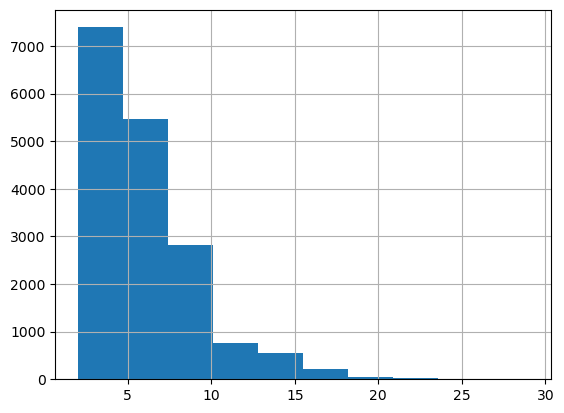

In [1161]:
print ("Number of records per person")
long_df['patid'].value_counts().hist()

In [1163]:
#take the earliest age ONLY for some diagnoses
first_only = ["parkinson", "diabetes", "dem_alzheimer", "cancer", "eye", "hysterectomy", "depression", "cholesterol", "arthritis"]

# make sure we are sorted by age within a patient
long_df = long_df.sort_values(['patid','age'])

# create row with rownumbers to drop some later 
long_df["rowid"] = range(len(long_df.patid))

# cycle over first-only conditions and get the list of "rowid" corresponding to duplicated rows 
# (in a sense of same first-only conditions for the same patient)
i = np.empty(0, dtype = int)
for idx in range(len(first_only)):
    d1 = long_df[long_df.event == first_only[idx]].duplicated(subset=['patid', 'event'], keep='first')
    i1 = long_df[long_df.event == first_only[idx]][d1]["rowid"] #get rowids to delete, duplicated for the same condition
    i = np.concatenate((i, i1))
i = np.unique(i) #these are all to delete

print (long_df.shape)
# now disselect those rowids 
long_df = long_df[~long_df['rowid'].isin(i)]
print (long_df.shape)

(100836, 8)
(89873, 8)


In [1165]:
long_df.loc[long_df.patid == 909775, :] #example - should be only one arthritis at 16 yo

,patid,age,event,sex,wealth,edu,eth,rowid
119254,909775,0.00,born,1,1.0,1.0,0.0,100831
119255,909775,16.00,arthritis,1,1.0,1.0,0.0,100832
119257,909775,51.25,cvd,1,1.0,1.0,0.0,100834
119259,909775,51.25,cholesterol,1,1.0,1.0,0.0,100835


In [1167]:
# SAVE THE DATA
print("Final dim", long_df.shape) #Final dim (89873, 8)
long_df.to_csv("ELSA data\ELSA_long_df.csv") 

Final dim (89873, 8)


In [1171]:
100067
long_df.loc[long_df.patid == 100067, :] 

,patid,age,event,sex,wealth,edu,eth,rowid
245,100067,0.00,born,0,2.0,2.0,0.0,196
246,100067,22.00,arthritis,0,2.0,2.0,0.0,197
247,100067,65.00,cvd,0,2.0,2.0,0.0,198
249,100067,71.33,bones,0,2.0,2.0,0.0,199
250,100067,71.33,cvd,0,2.0,2.0,0.0,200
255,100067,75.00,died,0,2.0,2.0,0.0,202
